# Matplotlib vs. Seaborn: Ein praktischer Vergleich

## Für den HsH Data Visualization Kurs

### Lernziele
Nach diesem Notebook können Sie:
1. Die Unterschiede zwischen Matplotlib und Seaborn erklären
2. Entscheiden, welche Bibliothek für welchen Zweck geeignet ist
3. Beide Bibliotheken effektiv kombinieren
4. Professionelle Visualisierungen erstellen

### Übersicht

**Matplotlib:**
- Low-level Plotting-Bibliothek
- Maximale Kontrolle und Flexibilität
- Mehr Code für komplexe Plots
- Basis für viele andere Bibliotheken

**Seaborn:**
- High-level Bibliothek (basiert auf Matplotlib)
- Schönere Standardstile
- Weniger Code für statistische Plots
- Integriert gut mit Pandas DataFrames

In [1]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
np.random.seed(42)

# Beispieldaten erstellen
n = 100
df = pd.DataFrame({
    'x': np.random.randn(n),
    'y': np.random.randn(n) * 2 + 1,
    'category': np.random.choice(['A', 'B', 'C'], n),
    'value': np.random.randint(10, 100, n)
})

print("✓ Bibliotheken geladen")
print(f"✓ Datensatz erstellt: {len(df)} Zeilen")
df.head()

✓ Bibliotheken geladen
✓ Datensatz erstellt: 100 Zeilen


,x,y,category,value
0,0.496714,-1.830741,B,95
1,-0.138264,0.158709,B,66
2,0.647689,0.314571,A,38
3,1.523030,-0.604555,A,87
4,-0.234153,0.677429,A,78


---

## 1. Scatter Plots: Vergleich

### Wann verwenden?
- Beziehung zwischen zwei kontinuierlichen Variablen zeigen
- Korrelationen visualisieren
- Ausreißer identifizieren

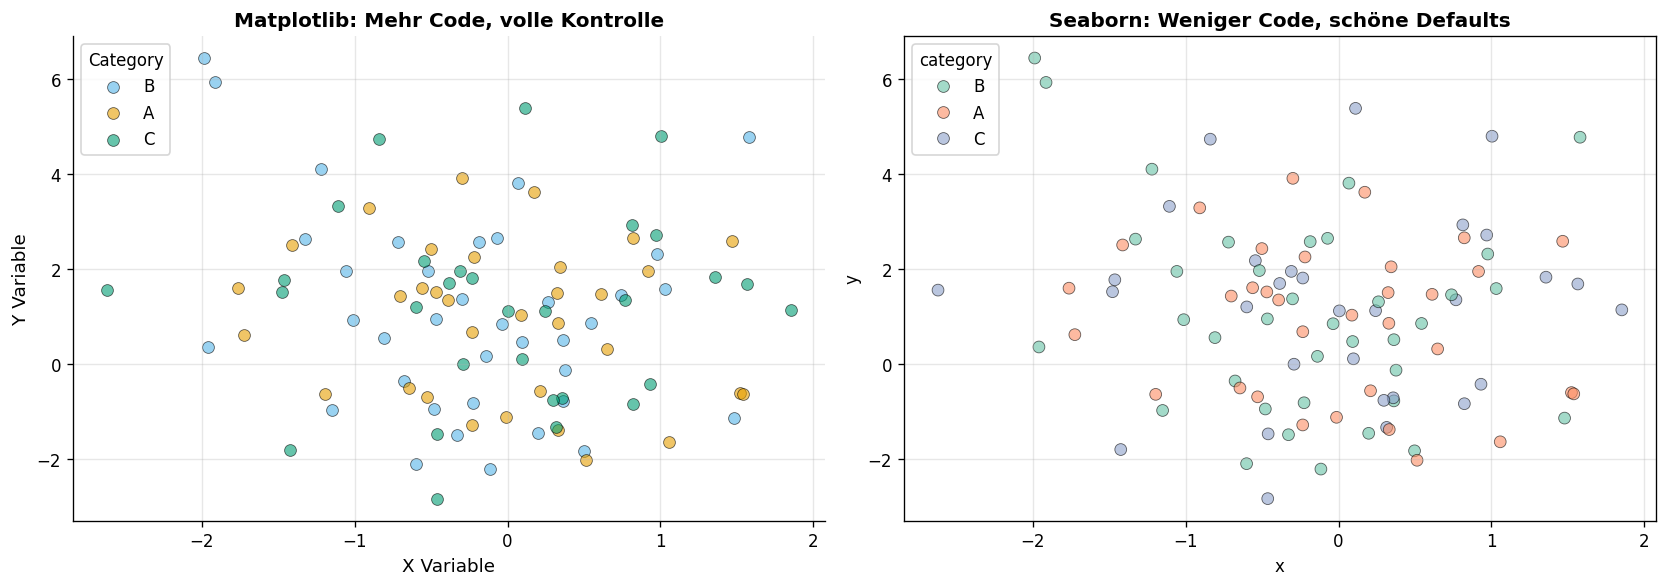


📊 Vergleich:
  Matplotlib: ~10 Zeilen Code, maximale Kontrolle
  Seaborn: ~2 Zeilen Code, automatische Legende und Farben


In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# MATPLOTLIB: Mehr Code, mehr Kontrolle
colors = {'A': '#E69F00', 'B': '#56B4E9', 'C': '#009E73'}
for category in df['category'].unique():
    mask = df['category'] == category
    ax1.scatter(df[mask]['x'], df[mask]['y'], 
                c=colors[category], label=category, 
                alpha=0.6, s=50, edgecolors='black', linewidth=0.5)

ax1.set_xlabel('X Variable', fontsize=11)
ax1.set_ylabel('Y Variable', fontsize=11)
ax1.set_title('Matplotlib: Mehr Code, volle Kontrolle', fontsize=12, fontweight='bold')
ax1.legend(title='Category', frameon=True)
ax1.grid(True, alpha=0.3)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# SEABORN: Weniger Code, schöne Defaults
sns.scatterplot(data=df, x='x', y='y', hue='category', 
                palette='Set2', alpha=0.6, s=50, 
                edgecolor='black', linewidth=0.5, ax=ax2)
ax2.set_title('Seaborn: Weniger Code, schöne Defaults', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📊 Vergleich:")
print("  Matplotlib: ~10 Zeilen Code, maximale Kontrolle")
print("  Seaborn: ~2 Zeilen Code, automatische Legende und Farben")

---

## 2. Distributions: Histogramme und KDE

### Wann verwenden?
- Verteilung einer Variable verstehen
- Normalverteilung prüfen
- Mehrere Gruppen vergleichen

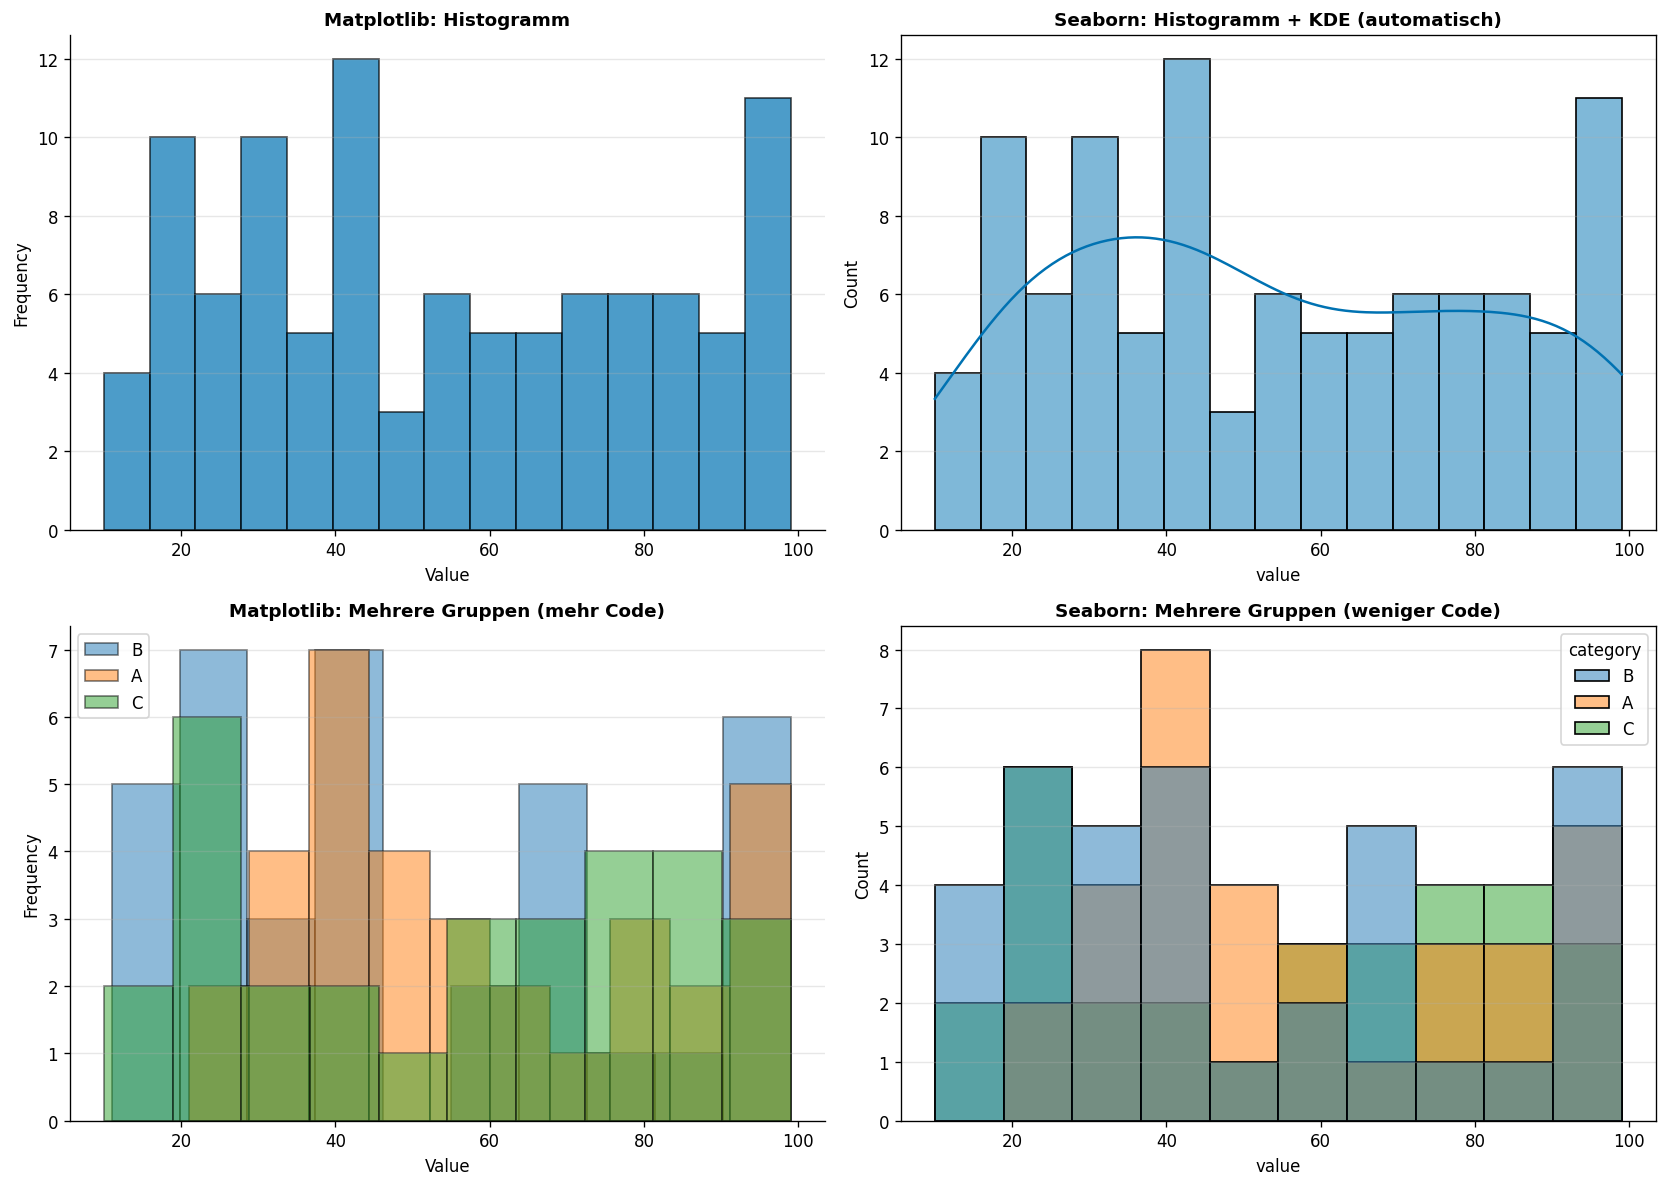


📊 Seaborn-Vorteil:
  • KDE automatisch hinzufügen mit kde=True
  • Mehrere Gruppen mit hue-Parameter
  • Automatische Farbpaletten


In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10), dpi=120)

# MATPLOTLIB: Histogramm
axes[0, 0].hist(df['value'], bins=15, color='#0072B2', alpha=0.7, edgecolor='black')
axes[0, 0].set_xlabel('Value', fontsize=10)
axes[0, 0].set_ylabel('Frequency', fontsize=10)
axes[0, 0].set_title('Matplotlib: Histogramm', fontsize=11, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3, axis='y')
axes[0, 0].spines['top'].set_visible(False)
axes[0, 0].spines['right'].set_visible(False)

# SEABORN: Histogramm mit KDE
sns.histplot(data=df, x='value', bins=15, kde=True, color='#0072B2', ax=axes[0, 1])
axes[0, 1].set_title('Seaborn: Histogramm + KDE (automatisch)', fontsize=11, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# MATPLOTLIB: Mehrere Gruppen (kompliziert)
for i, category in enumerate(df['category'].unique()):
    data = df[df['category'] == category]['value']
    axes[1, 0].hist(data, bins=10, alpha=0.5, label=category, edgecolor='black')
axes[1, 0].set_xlabel('Value', fontsize=10)
axes[1, 0].set_ylabel('Frequency', fontsize=10)
axes[1, 0].set_title('Matplotlib: Mehrere Gruppen (mehr Code)', fontsize=11, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3, axis='y')
axes[1, 0].spines['top'].set_visible(False)
axes[1, 0].spines['right'].set_visible(False)

# SEABORN: Mehrere Gruppen (einfach)
sns.histplot(data=df, x='value', hue='category', bins=10, 
             multiple='layer', alpha=0.5, ax=axes[1, 1])
axes[1, 1].set_title('Seaborn: Mehrere Gruppen (weniger Code)', fontsize=11, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Seaborn-Vorteil:")
print("  • KDE automatisch hinzufügen mit kde=True")
print("  • Mehrere Gruppen mit hue-Parameter")
print("  • Automatische Farbpaletten")

---

## 3. Statistische Plots: Seaborns Stärke

### Seaborn ist ideal für:
- Boxplots, Violinplots
- Regression plots
- Heatmaps
- Pairplots

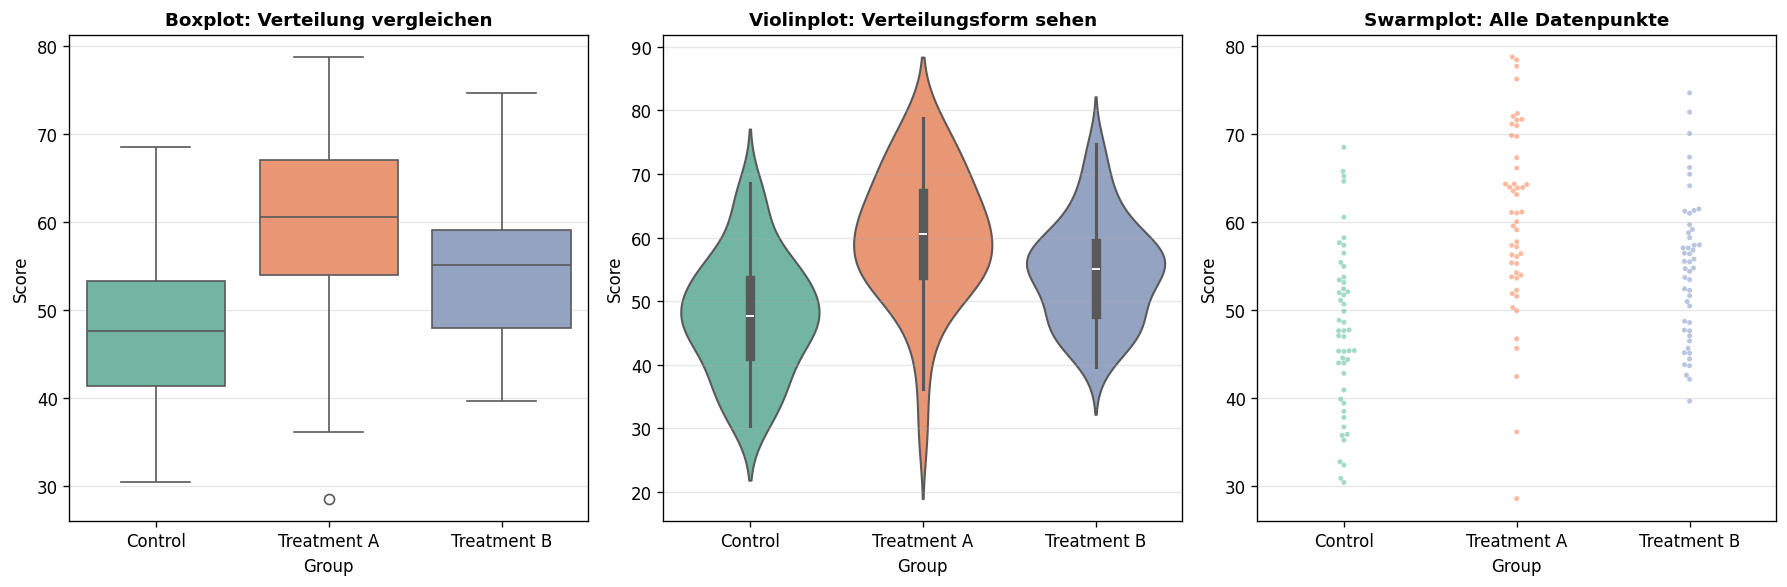


📊 Diese Plots in Matplotlib zu erstellen wäre sehr aufwendig!
  Seaborn macht statistische Visualisierungen einfach.


In [4]:
# Erweiterte Daten für statistische Plots
np.random.seed(42)
stats_df = pd.DataFrame({
    'Group': np.repeat(['Control', 'Treatment A', 'Treatment B'], 50),
    'Score': np.concatenate([
        np.random.normal(50, 10, 50),
        np.random.normal(60, 12, 50),
        np.random.normal(55, 8, 50)
    ])
})

fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=120)

# Boxplot
sns.boxplot(data=stats_df, x='Group', y='Score', palette='Set2', ax=axes[0])
axes[0].set_title('Boxplot: Verteilung vergleichen', fontsize=11, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')

# Violinplot (zeigt Verteilungsform)
sns.violinplot(data=stats_df, x='Group', y='Score', palette='Set2', ax=axes[1])
axes[1].set_title('Violinplot: Verteilungsform sehen', fontsize=11, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

# Swarmplot (alle Datenpunkte)
sns.swarmplot(data=stats_df, x='Group', y='Score', palette='Set2', 
              size=3, alpha=0.6, ax=axes[2])
axes[2].set_title('Swarmplot: Alle Datenpunkte', fontsize=11, fontweight='bold')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\n📊 Diese Plots in Matplotlib zu erstellen wäre sehr aufwendig!")
print("  Seaborn macht statistische Visualisierungen einfach.")

---

## 4. Heatmaps: Korrelationen visualisieren

### Wann verwenden?
- Korrelationsmatrizen
- Zeitreihen-Muster
- Konfusionsmatrizen

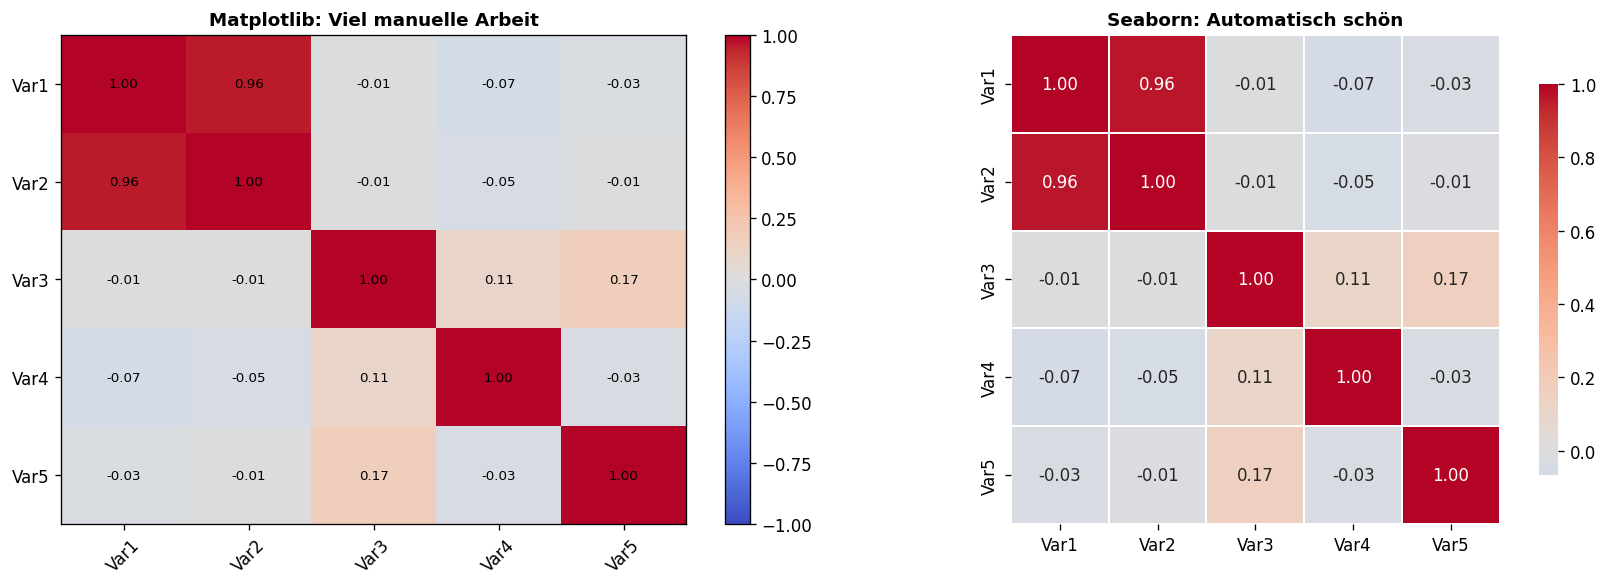


📊 Seaborn Heatmap-Vorteile:
  • annot=True: Werte automatisch anzeigen
  • fmt='.2f': Formatierung einfach
  • center=0: Farbskala zentrieren
  • square=True: Quadratische Zellen


In [5]:
# Korrelationsmatrix erstellen
corr_data = pd.DataFrame(np.random.randn(100, 5), 
                         columns=['Var1', 'Var2', 'Var3', 'Var4', 'Var5'])
corr_data['Var2'] = corr_data['Var1'] * 0.8 + np.random.randn(100) * 0.2
correlation = corr_data.corr()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5), dpi=120)

# MATPLOTLIB: Viel manuelle Arbeit
im = ax1.imshow(correlation, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
ax1.set_xticks(range(len(correlation.columns)))
ax1.set_yticks(range(len(correlation.columns)))
ax1.set_xticklabels(correlation.columns, rotation=45)
ax1.set_yticklabels(correlation.columns)
ax1.set_title('Matplotlib: Viel manuelle Arbeit', fontsize=11, fontweight='bold')

# Werte hinzufügen (manuell)
for i in range(len(correlation)):
    for j in range(len(correlation)):
        text = ax1.text(j, i, f'{correlation.iloc[i, j]:.2f}',
                       ha='center', va='center', color='black', fontsize=8)

plt.colorbar(im, ax=ax1)

# SEABORN: Automatisch schön
sns.heatmap(correlation, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={'shrink': 0.8}, ax=ax2)
ax2.set_title('Seaborn: Automatisch schön', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 Seaborn Heatmap-Vorteile:")
print("  • annot=True: Werte automatisch anzeigen")
print("  • fmt='.2f': Formatierung einfach")
print("  • center=0: Farbskala zentrieren")
print("  • square=True: Quadratische Zellen")

---

## 5. Styling: Themes und Anpassungen

### Seaborn Themes
Seaborn bietet vordefinierte Themes für professionelle Plots.

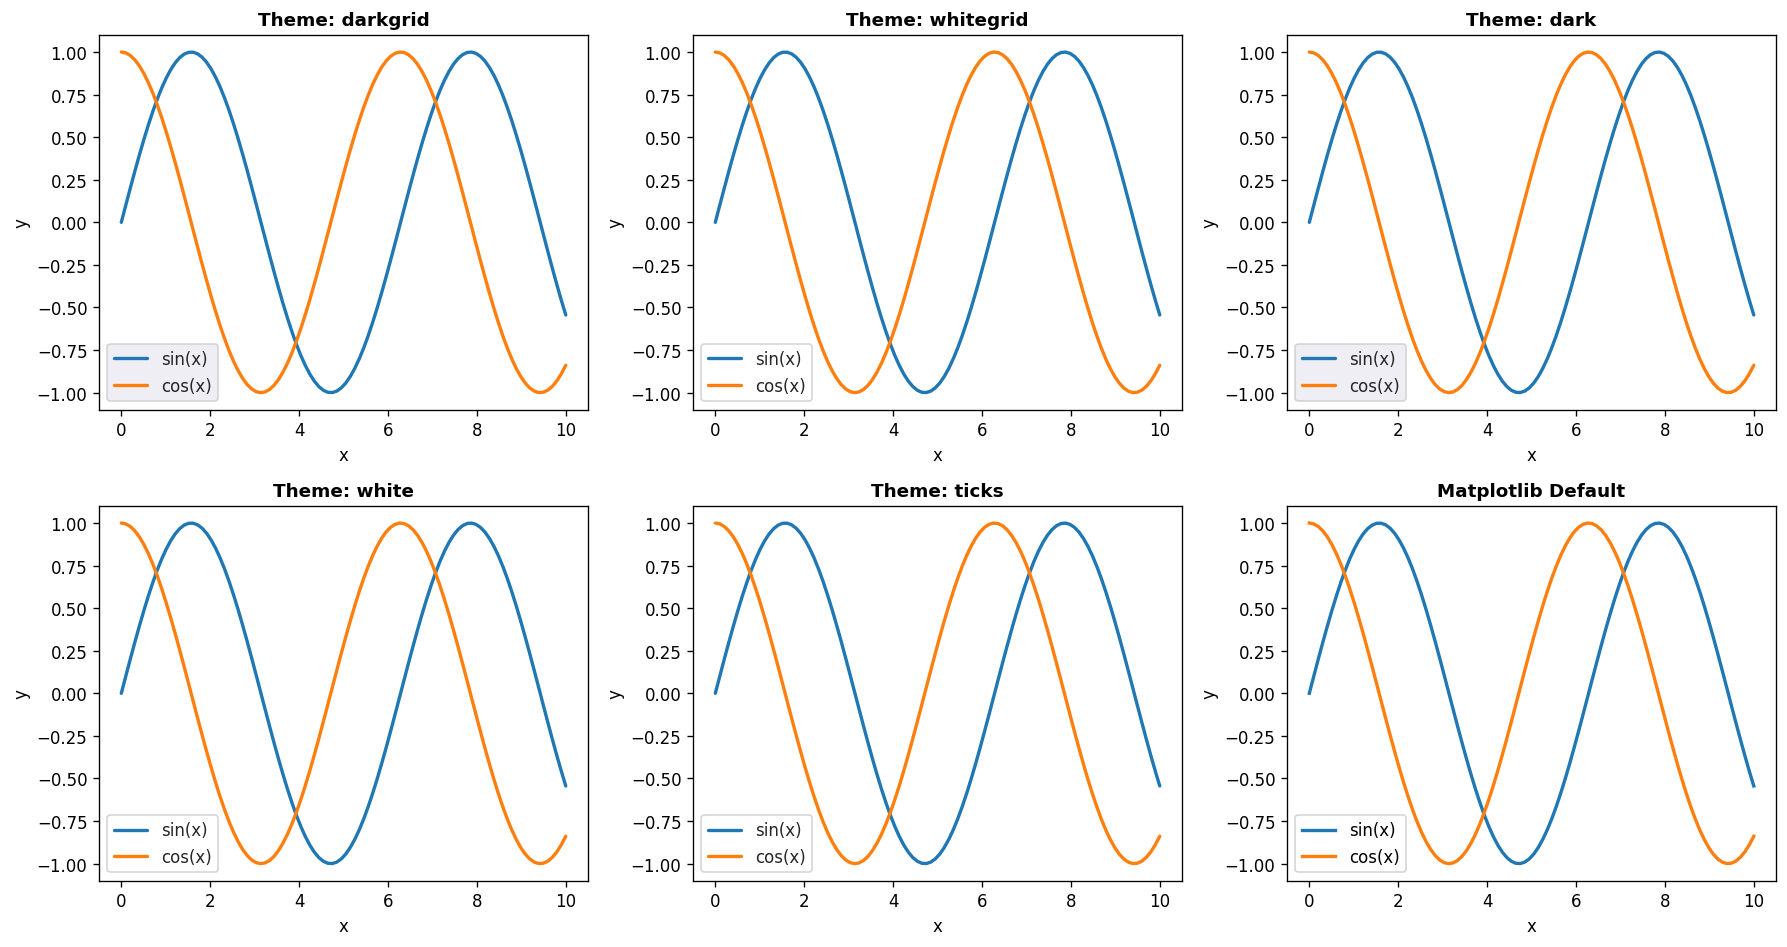


🎨 Seaborn Themes:
  • darkgrid: Dunkles Gitter (gut für Präsentationen)
  • whitegrid: Helles Gitter (Standard)
  • dark/white: Ohne Gitter
  • ticks: Nur Achsenmarkierungen


In [6]:
# Beispieldaten
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)

themes = ['darkgrid', 'whitegrid', 'dark', 'white', 'ticks']
fig, axes = plt.subplots(2, 3, figsize=(15, 8), dpi=120)
axes = axes.ravel()

for i, theme in enumerate(themes):
    sns.set_style(theme)
    ax = axes[i]
    ax.plot(x, y1, label='sin(x)', linewidth=2)
    ax.plot(x, y2, label='cos(x)', linewidth=2)
    ax.set_title(f'Theme: {theme}', fontsize=11, fontweight='bold')
    ax.legend()
    ax.set_xlabel('x')
    ax.set_ylabel('y')

# Letztes Panel: Matplotlib default
plt.style.use('default')
axes[5].plot(x, y1, label='sin(x)', linewidth=2)
axes[5].plot(x, y2, label='cos(x)', linewidth=2)
axes[5].set_title('Matplotlib Default', fontsize=11, fontweight='bold')
axes[5].legend()
axes[5].set_xlabel('x')
axes[5].set_ylabel('y')

plt.tight_layout()
plt.show()

# Reset zu default
sns.set_style('whitegrid')

print("\n🎨 Seaborn Themes:")
print("  • darkgrid: Dunkles Gitter (gut für Präsentationen)")
print("  • whitegrid: Helles Gitter (Standard)")
print("  • dark/white: Ohne Gitter")
print("  • ticks: Nur Achsenmarkierungen")

---

## 6. Kombination: Das Beste aus beiden Welten

### Best Practice
Seaborn für schnelle, schöne Plots + Matplotlib für Feintuning

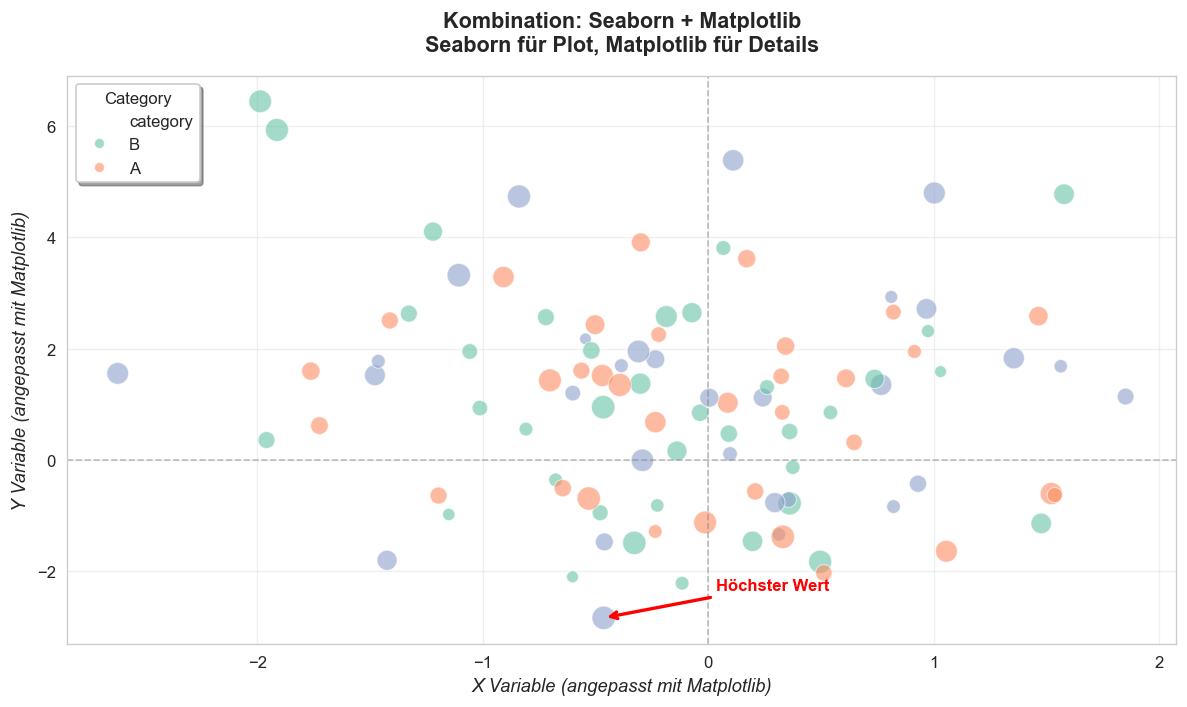


✨ Best Practice:
  1. Seaborn für den Basis-Plot (schnell, schön)
  2. Matplotlib für Feintuning (Annotationen, Linien, etc.)
  3. Beide Bibliotheken ergänzen sich perfekt!


In [7]:
# Seaborn für den Plot, Matplotlib für Anpassungen
fig, ax = plt.subplots(figsize=(10, 6), dpi=120)

# Seaborn: Schneller, schöner Plot
sns.scatterplot(data=df, x='x', y='y', hue='category', 
                size='value', sizes=(50, 200), 
                palette='Set2', alpha=0.6, ax=ax)

# Matplotlib: Feintuning
ax.set_title('Kombination: Seaborn + Matplotlib\nSeaborn für Plot, Matplotlib für Details', 
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('X Variable (angepasst mit Matplotlib)', fontsize=11, style='italic')
ax.set_ylabel('Y Variable (angepasst mit Matplotlib)', fontsize=11, style='italic')

# Matplotlib: Annotationen hinzufügen
max_point = df.loc[df['value'].idxmax()]
ax.annotate('Höchster Wert', 
            xy=(max_point['x'], max_point['y']),
            xytext=(max_point['x'] + 0.5, max_point['y'] + 0.5),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=10, color='red', weight='bold')

# Matplotlib: Referenzlinien
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)
ax.axvline(x=0, color='gray', linestyle='--', linewidth=1, alpha=0.5)

# Matplotlib: Legende anpassen
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles[:3], labels[:3], title='Category', 
          loc='upper left', frameon=True, shadow=True)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✨ Best Practice:")
print("  1. Seaborn für den Basis-Plot (schnell, schön)")
print("  2. Matplotlib für Feintuning (Annotationen, Linien, etc.)")
print("  3. Beide Bibliotheken ergänzen sich perfekt!")

---

## Entscheidungshilfe: Wann was verwenden?

### Verwende MATPLOTLIB wenn:
✓ Du maximale Kontrolle brauchst  
✓ Du sehr spezifische Anpassungen machen willst  
✓ Du mit Arrays/NumPy arbeitest  
✓ Du komplexe, custom Plots erstellst  
✓ Du Subplots mit unterschiedlichen Plot-Typen kombinierst  

### Verwende SEABORN wenn:
✓ Du schnell schöne Plots erstellen willst  
✓ Du mit Pandas DataFrames arbeitest  
✓ Du statistische Visualisierungen brauchst  
✓ Du Daten nach Kategorien gruppieren willst  
✓ Du Korrelationen oder Distributionen zeigen willst  

### Verwende BEIDE wenn:
✓ Du Seaborns Einfachheit + Matplotlibs Kontrolle willst  
✓ Du Annotationen zu Seaborn-Plots hinzufügen willst  
✓ Du das Layout feintunen musst  

---

## Code-Vergleich: Zusammenfassung

### Scatter Plot mit Kategorien

**Matplotlib:** ~10-15 Zeilen  
**Seaborn:** 1-2 Zeilen  

### Histogramm mit mehreren Gruppen

**Matplotlib:** ~8-10 Zeilen + Loop  
**Seaborn:** 1 Zeile mit `hue`-Parameter  

### Heatmap mit Annotationen

**Matplotlib:** ~20+ Zeilen  
**Seaborn:** 1 Zeile mit `annot=True`  

---

## Praktische Tipps

### 1. Seaborn-Stil global setzen
```python
sns.set_style('whitegrid')
sns.set_context('talk')  # Größere Schrift für Präsentationen
```

### 2. Farbpaletten
```python
# Seaborn Paletten
sns.color_palette('Set2')  # Qualitativ
sns.color_palette('viridis')  # Sequenziell
sns.color_palette('RdBu_r')  # Divergierend
```

### 3. Figure und Axes
```python
# Immer mit fig, ax arbeiten für Kontrolle
fig, ax = plt.subplots()
sns.scatterplot(data=df, x='x', y='y', ax=ax)
ax.set_title('Mein Titel')  # Matplotlib für Anpassungen
```

---

## Übungsaufgaben

### Aufgabe 1: Scatter Plot
Erstelle einen Scatter Plot mit Seaborn, der:
- x und y aus dem DataFrame plottet
- Nach 'category' färbt
- Größe basierend auf 'value' hat
- Eine Regressionslinie zeigt (Tipp: `sns.regplot`)

### Aufgabe 2: Distribution
Erstelle einen Plot, der die Verteilung von 'value' für jede Kategorie zeigt:
- Verwende `sns.violinplot` oder `sns.boxplot`
- Füge mit Matplotlib eine horizontale Linie beim Median hinzu
- Passe Titel und Labels an

### Aufgabe 3: Kombination
Erstelle einen Seaborn-Plot und füge mit Matplotlib hinzu:
- Eine Annotation für einen interessanten Punkt
- Referenzlinien
- Einen custom Titel mit Untertitel

---

## Ressourcen

### Dokumentation
- [Matplotlib Docs](https://matplotlib.org/stable/contents.html)
- [Seaborn Gallery](https://seaborn.pydata.org/examples/index.html)
- [Seaborn Tutorial](https://seaborn.pydata.org/tutorial.html)

### Cheat Sheets
- [Matplotlib Cheat Sheet](https://matplotlib.org/cheatsheets/)
- [Seaborn Cheat Sheet](https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Python_Seaborn_Cheat_Sheet.pdf)

---

*Erstellt für den HsH Data Visualization Kurs - April 2026*